In [1]:
import numpy as np
import json
import torch
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


Пути к каталогам.

In [3]:
config_dir = Path("./config/")
dataset_dir = Path('./zeros-poles-dataset/')

Загрузка файла конфигурации.

In [4]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

Проверка генерации масок.

In [5]:
from utils.general_functions import generate_masks

masks = generate_masks(masks={}, configer=configer)
mask_dict = masks["1zp2lp1rp2lz1rz_001"]
print(mask_dict)

{'zero_poles': 1, 'left_poles': [108, 32], 'right_poles': [320], 'left_zeros': [274, 399], 'right_zeros': [192]}


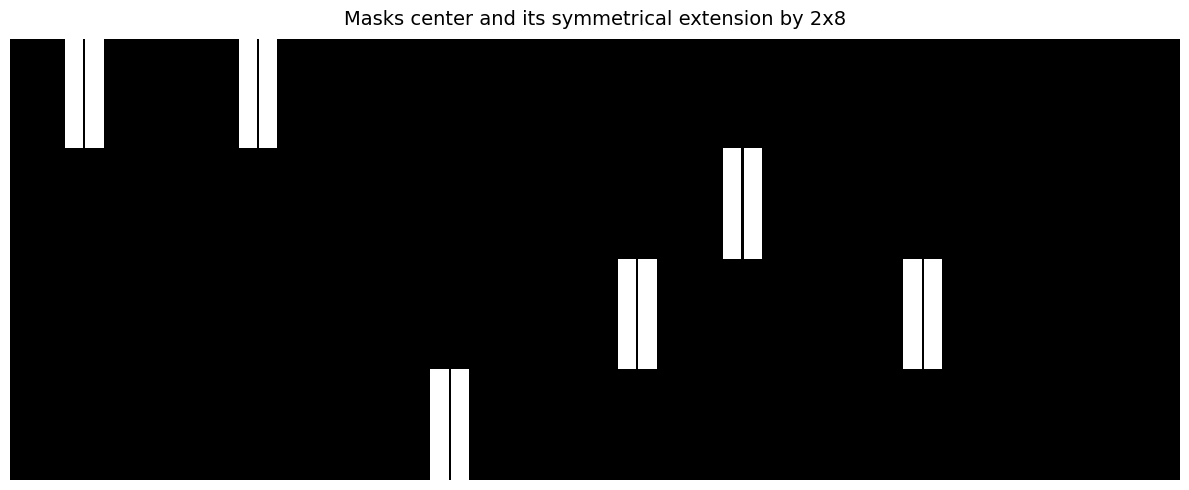

In [6]:
from utils.ZerosPolesDataset import positions_to_mask

halfwindow_list = [0, 8]

# Collect differences in a single loop
diff_masks = []

for key, positions in mask_dict.items():
    if key == 'zero_poles':
        continue
    mask = []
    for hw in halfwindow_list:
        mask.append(
            positions_to_mask(
                positions=positions,
                total_bits=configer['length'],
                halfwindow=hw
            )
        )

    diff = np.abs(np.array(mask[0], dtype=int) - np.array(mask[-1], dtype=int))
    diff_masks.append(diff)

plt.figure(figsize=(12, 5))
plt.imshow(diff_masks, cmap='gray', aspect='auto', interpolation='nearest')
plt.title(f'Masks center and its symmetrical extension by 2x{halfwindow_list[1]}', fontsize=14, pad=10)
plt.axis('off')
plt.tight_layout()
plt.show()

## Пример работы с dataloader

In [7]:
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [8]:
from utils.ZerosPolesDataset import ZerosPolesDataset, TransformsConfig

N_samples = 8
split = configer['split']

# Пути к маскам.
mask_path = Path(dataset_dir) / (split + "_masks.json")
assert mask_path.exists(), f"Mask not found: {mask_path}"
with open(mask_path, "r") as f:
    masks = json.load(f)

# Полный перечень ключей.    
samples_full = list(masks.keys())

# Случайная выборка данных.
samples = np.random.choice(samples_full, size=N_samples, replace=False).tolist()

### Визуализация выбранных данных

In [9]:
from utils.plot_functions import plot_responses

In [10]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 8,
    'fig_height_per_row': 2,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Phase',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph'
        },
        {
            'ylabel': 'Diff 1 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_mag'
        },
        {
            'ylabel': 'Diff 1 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_ph'
        },
        {
            'ylabel': 'Diff 2 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_mag'
        },
        {
            'ylabel': 'Diff 2 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_ph'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

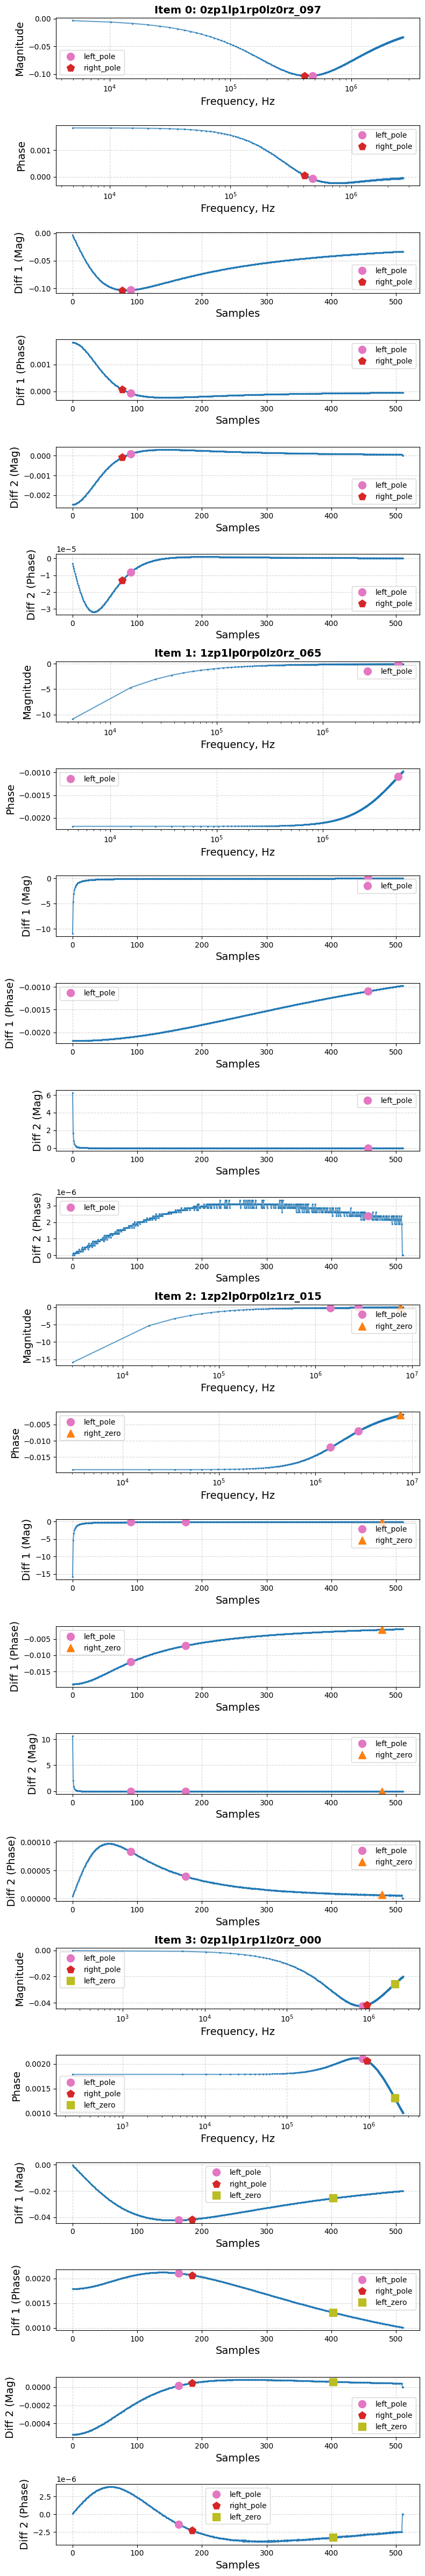

In [11]:
dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples
)

plot_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

In [20]:
from utils.plot_functions import plot_frequency_responses

Конфигуратор стиля графиков.

In [21]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 14,
    'fig_height_per_row': 4,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'mag_db'
        },
        {
            'ylabel': 'Gain (Real)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'real'
        },
        {
            'ylabel': 'Phase, deg',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph_deg'
        },
        {
            'ylabel': 'Gain (Imag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'imag'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

#### Нет аугментаций

ValueError: not enough values to unpack (expected 4, got 3)

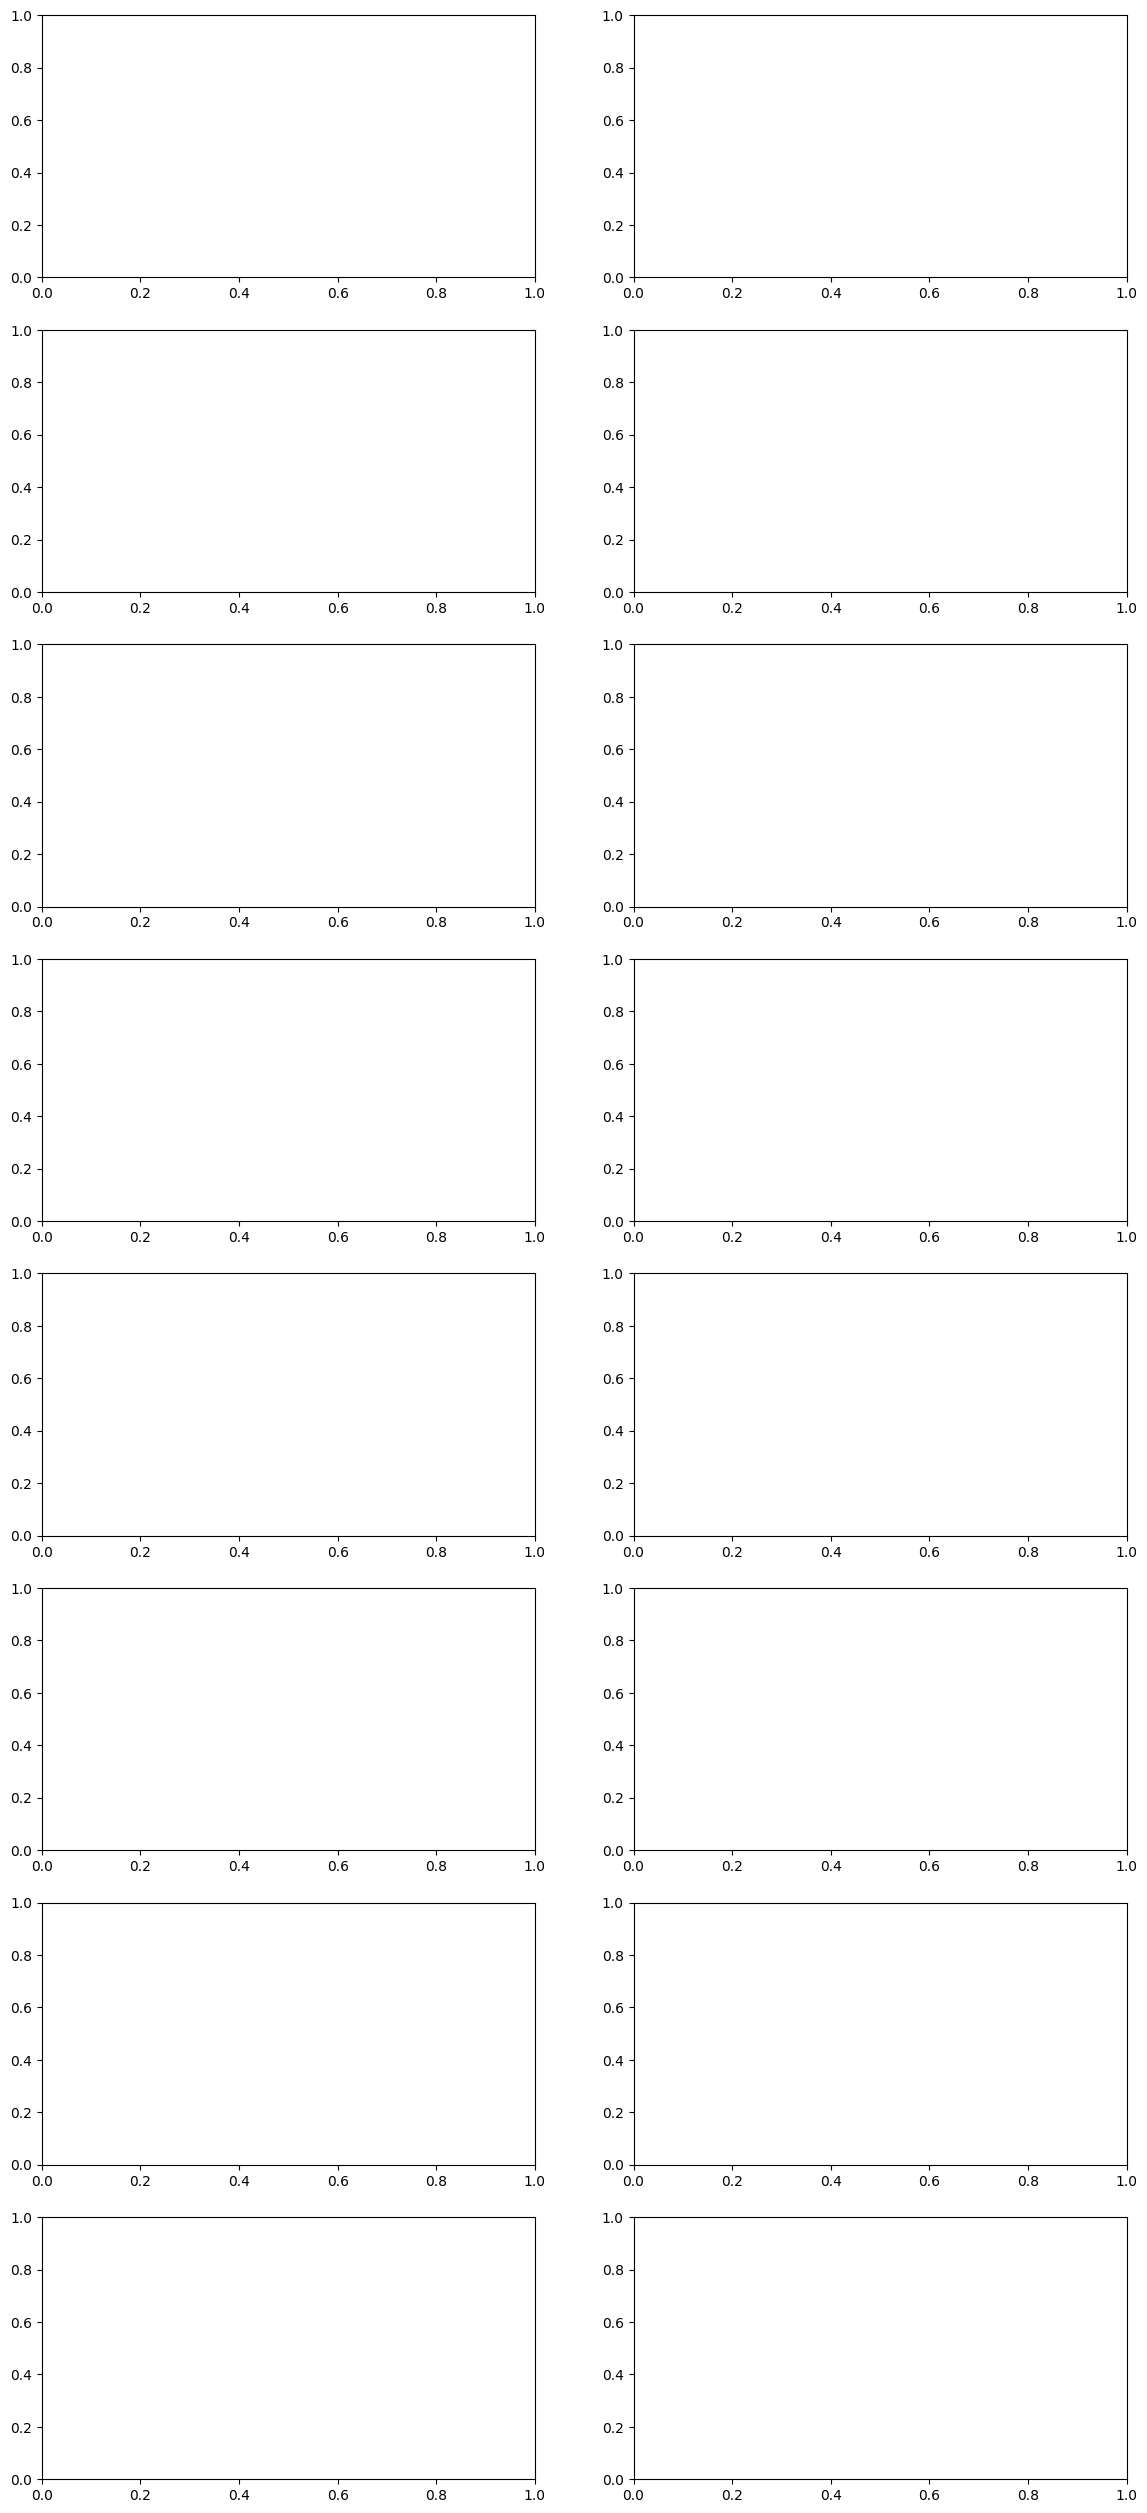

In [ ]:
plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

### Визуализация выбранных данных: аугментации

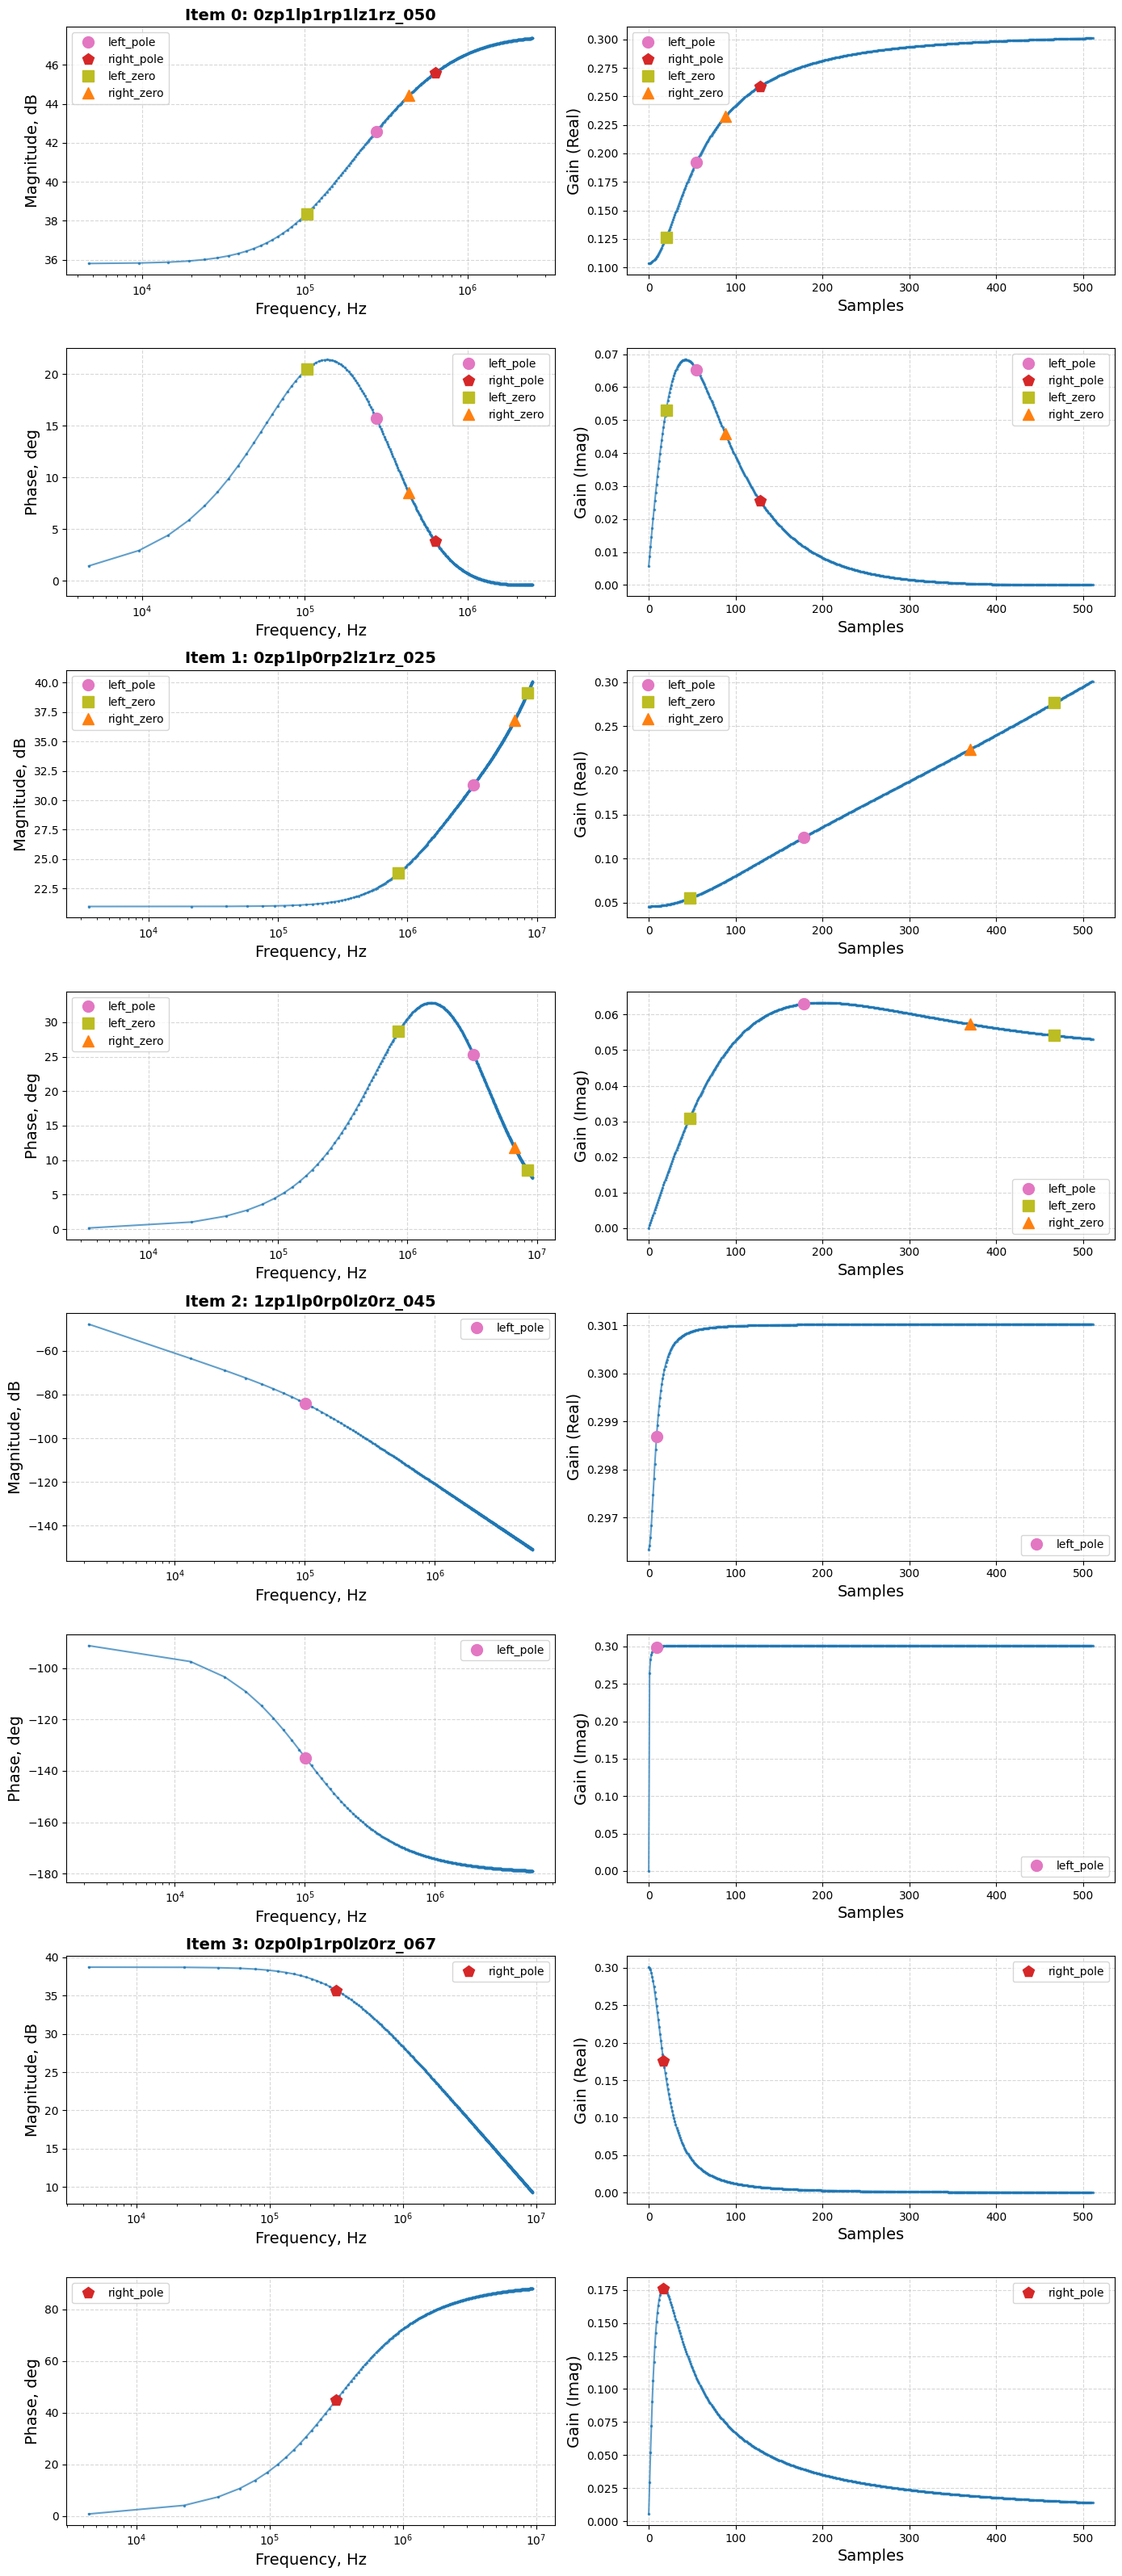

In [ ]:
custom_transforms = TransformsConfig(
    #crop_ratio=[1.0, 1.0],
    time_delay=[0.0, 1e-9],
    noise_level=[5e-3, 30e-3],
    noise_reduce=3,
    gain=[-1e3, 1e3]
)

dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples,
    #transforms=custom_transforms
)

plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/augmented_dataset_samples.png'))